#### Importing libararies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### Lets load the Boston House Pricing Dataset

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
boston=fetch_california_housing()

In [4]:
boston.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
# Lets check the description fo the dataset
print(boston.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
print(boston.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [7]:
print(boston.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [8]:
print(boston.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


#### Preparing The Dataset

In [9]:
dataset=pd.DataFrame(boston.data, columns=boston.feature_names)

In [10]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
dataset["Med_house_value"]=boston.target

In [12]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Med_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
dataset.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Med_house_value'],
      dtype='object')

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MedInc           20640 non-null  float64
 1   HouseAge         20640 non-null  float64
 2   AveRooms         20640 non-null  float64
 3   AveBedrms        20640 non-null  float64
 4   Population       20640 non-null  float64
 5   AveOccup         20640 non-null  float64
 6   Latitude         20640 non-null  float64
 7   Longitude        20640 non-null  float64
 8   Med_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
# Summarizing The Stats of the data
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Med_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [16]:
# Check the missing Values
dataset.isnull().sum()

MedInc             0
HouseAge           0
AveRooms           0
AveBedrms          0
Population         0
AveOccup           0
Latitude           0
Longitude          0
Med_house_value    0
dtype: int64

In [17]:
# Exploratory Data Analysis
# Correlation
corr=dataset.corr()

<Axes: >

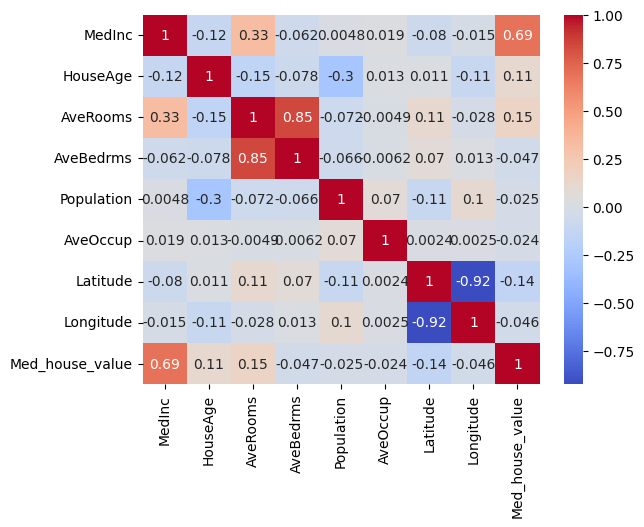

In [18]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

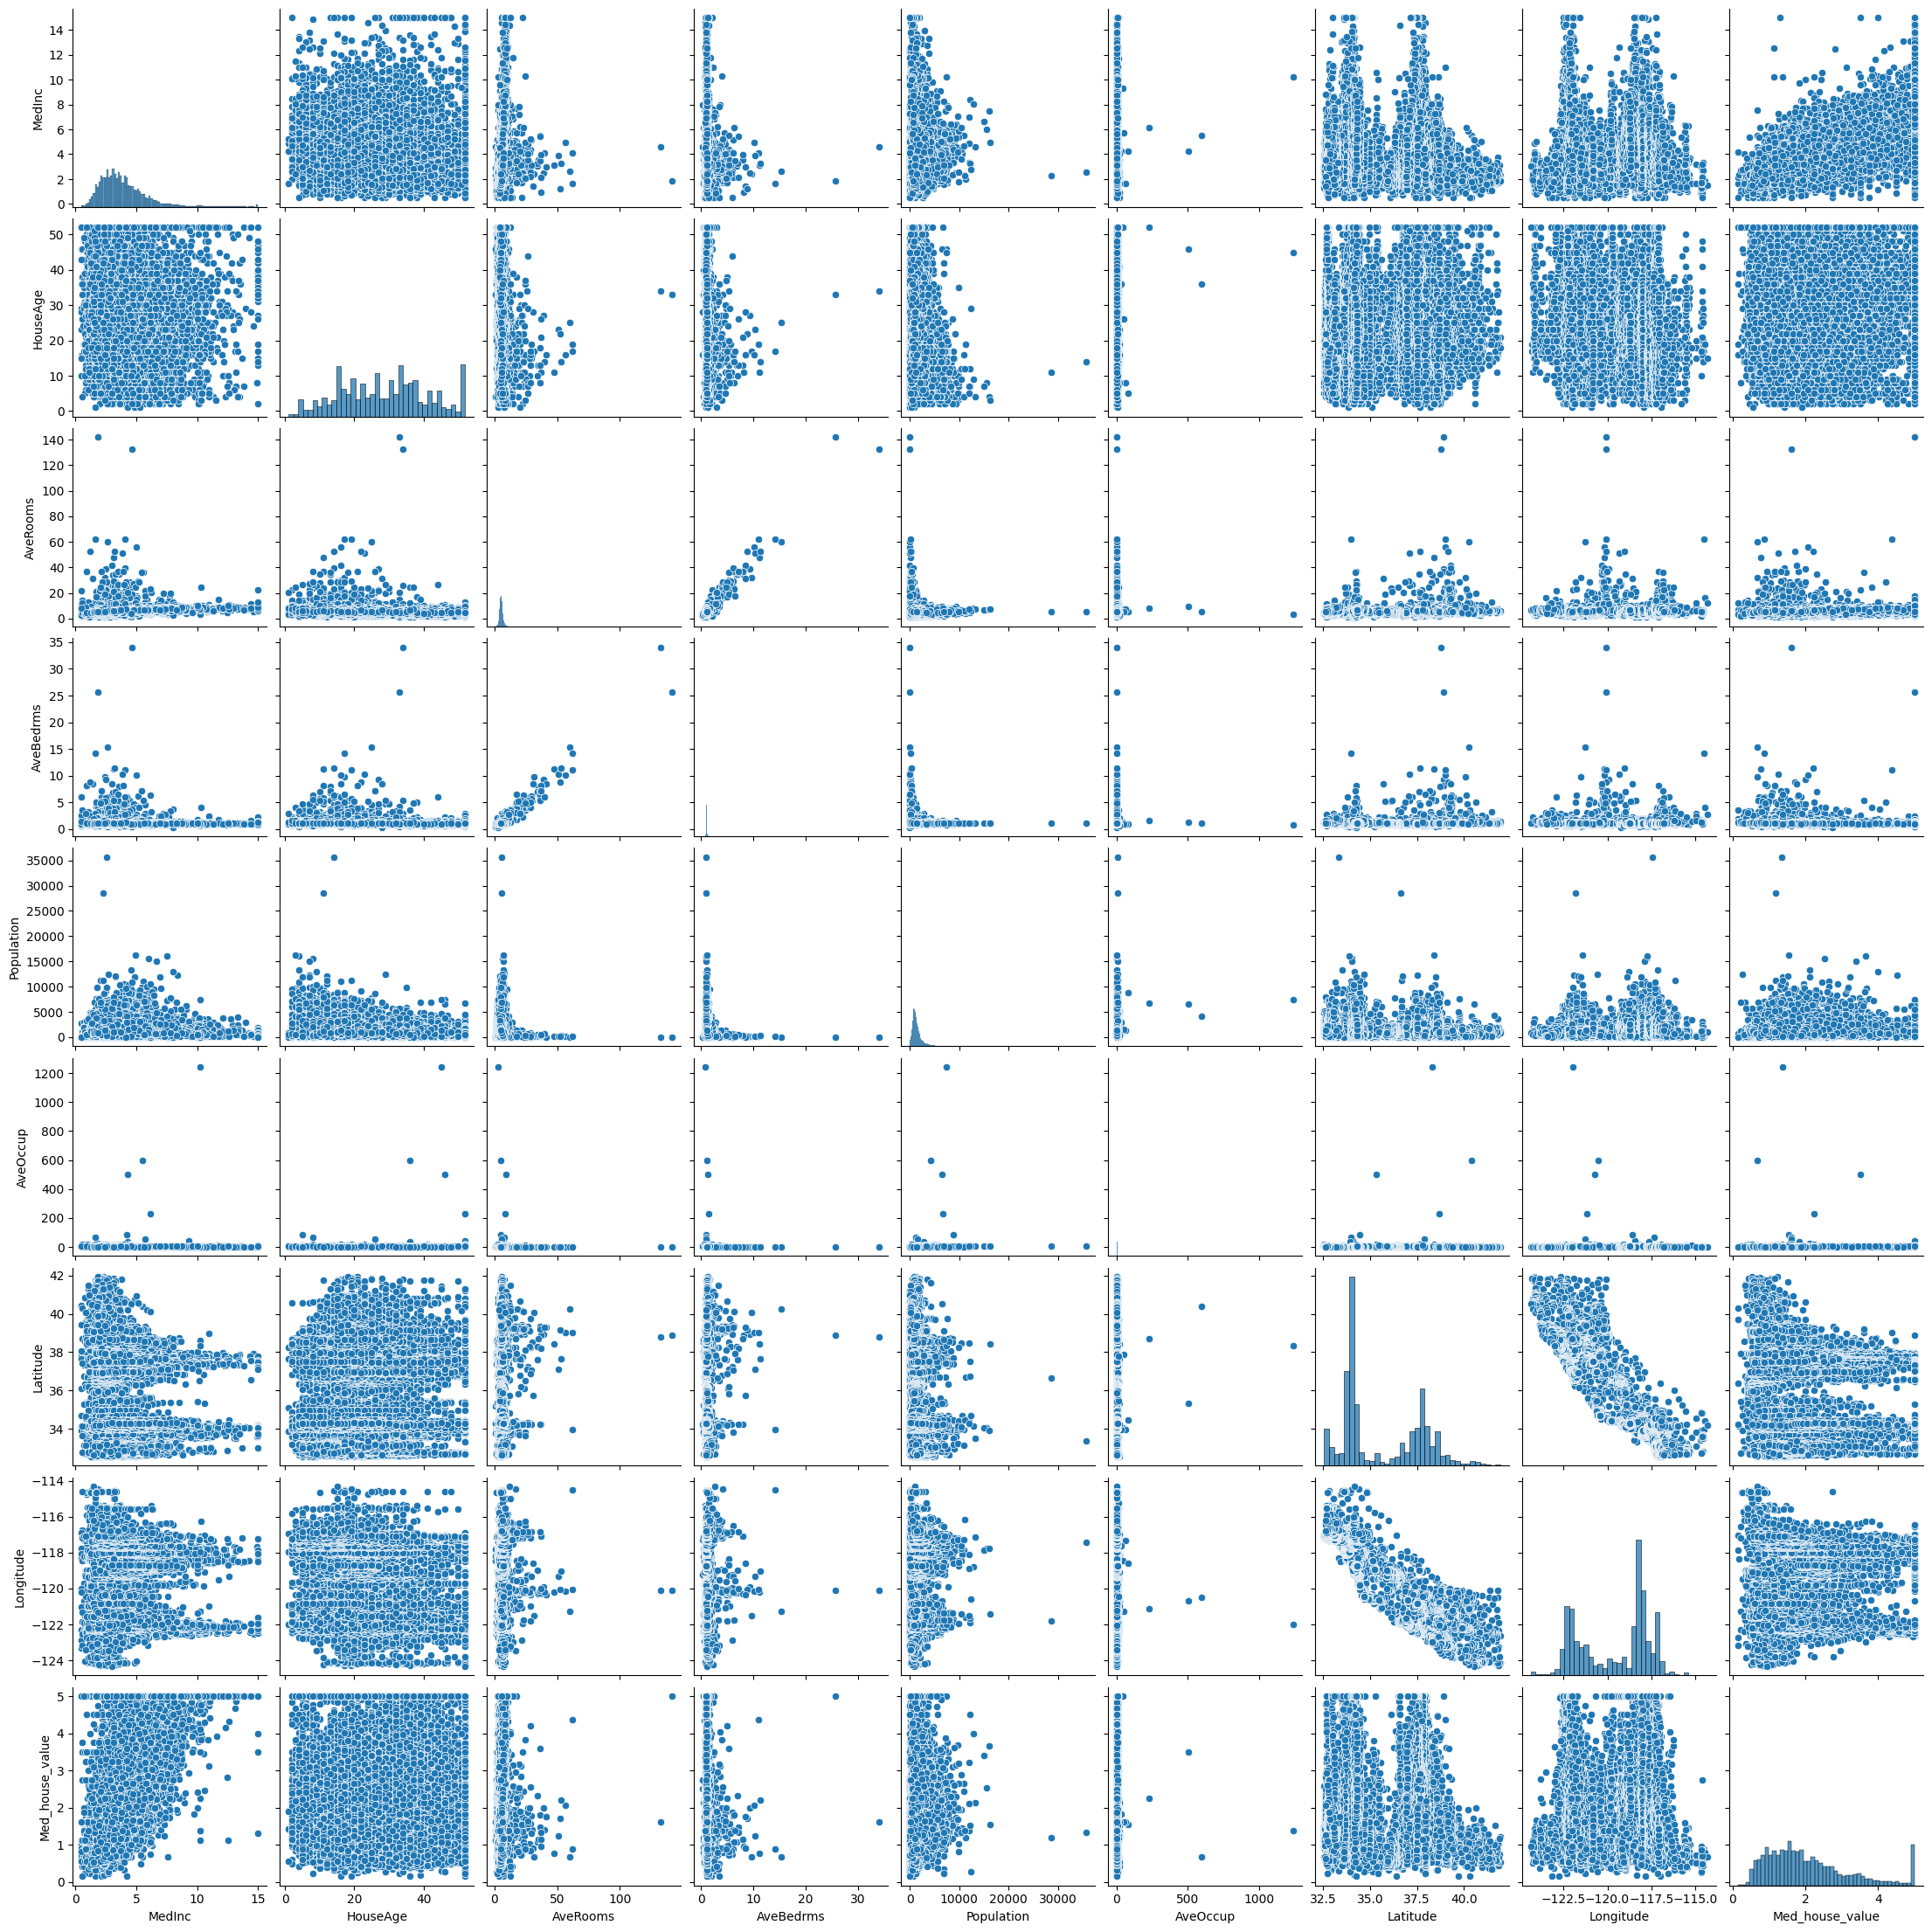

In [19]:
sns.pairplot(dataset)

#### Analyzing The Correlated Features

<Axes: >

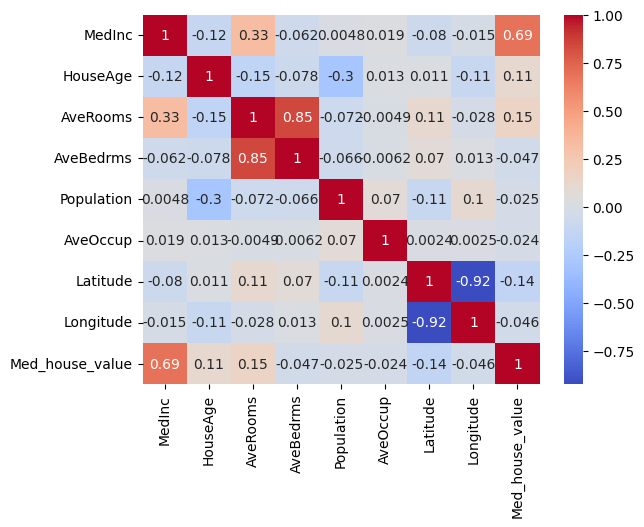

In [20]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

Text(0, 0.5, 'Median income')

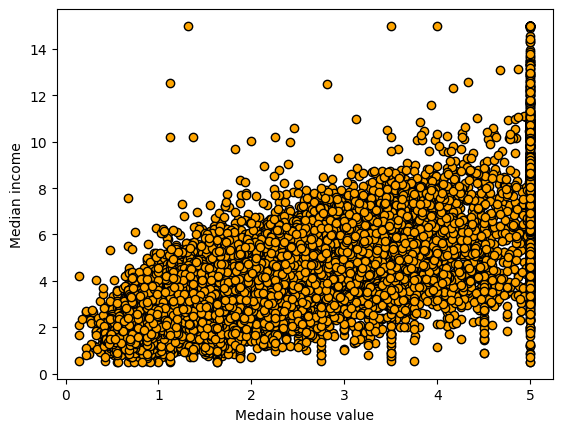

In [21]:
plt.scatter(dataset["Med_house_value"], dataset["MedInc"], color="orange", edgecolor="black")
plt.xlabel("Medain house value")
plt.ylabel("Median income")

Text(0, 0.5, 'Average bedrooms')

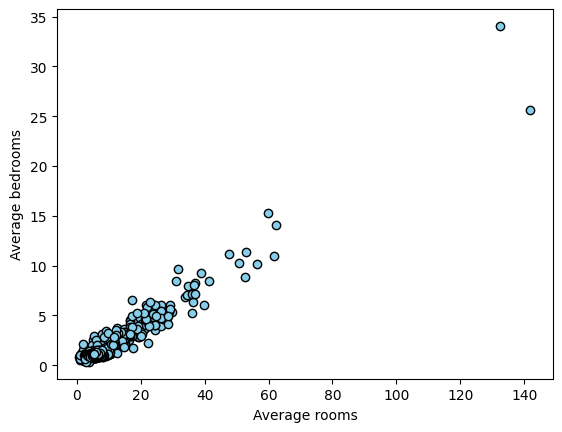

In [22]:
plt.scatter(dataset["AveRooms"], dataset["AveBedrms"], color="skyblue", edgecolor="black")
plt.xlabel("Average rooms")
plt.ylabel("Average bedrooms")

Text(0, 0.5, 'Population')

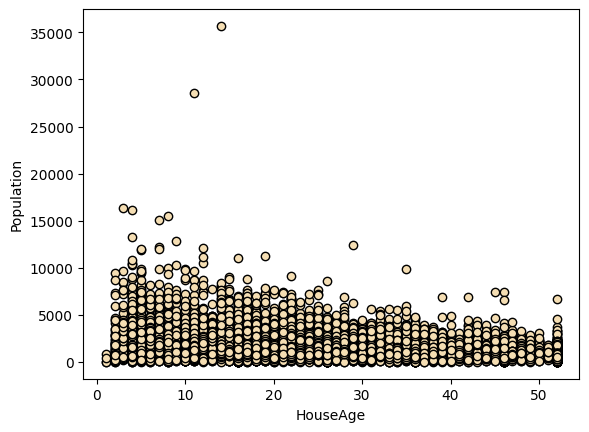

In [23]:
plt.scatter(dataset["HouseAge"], dataset["Population"], color="wheat", edgecolor="black")
plt.xlabel("HouseAge")
plt.ylabel("Population")

Text(0, 0.5, 'Median income')

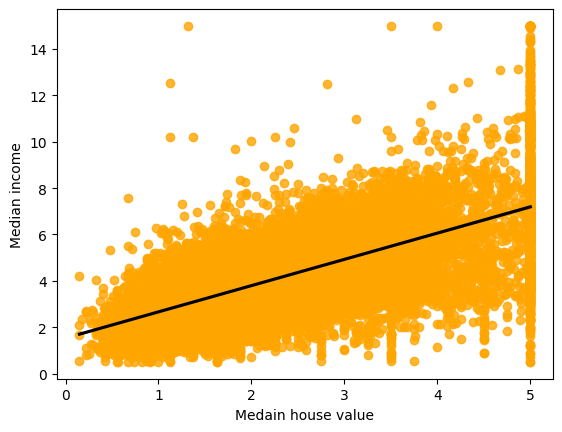

In [24]:
sns.regplot(x="Med_house_value", y="MedInc", data=dataset, color="orange", line_kws={"color":"black"})
plt.xlabel("Medain house value")
plt.ylabel("Median income")

In [ ]:
sns.regplot(x="AveRooms", y="AveBedrms", data=dataset, color="skyblue", line_kws={"color":"black"})
plt.xlabel("Average rooms")
plt.ylabel("Average bedrooms")

Text(0, 0.5, 'Average bedrooms')

Text(0, 0.5, 'Population')

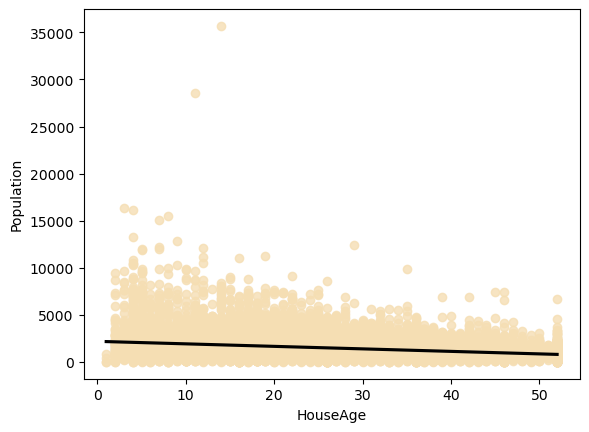

In [ ]:
sns.regplot(x="HouseAge", y="Population", data=dataset, color="wheat", line_kws={"color":"black"})
plt.xlabel("HouseAge")
plt.ylabel("Population")

In [ ]:
# Independent and Dependent features
X=dataset.iloc[:, :-1]
y=dataset.iloc[:, -1]

In [ ]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Med_house_value, Length: 20640, dtype: float64

In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [ ]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
17505,2.9545,47.0,4.195833,1.020833,581.0,2.420833,37.36,-121.90
13512,1.4891,41.0,4.551852,1.118519,994.0,3.681481,34.11,-117.32
10842,3.5120,16.0,3.762287,1.075614,5014.0,2.369565,33.67,-117.91
16559,3.6500,10.0,5.502092,1.060371,5935.0,3.547519,37.82,-121.28


In [ ]:
# Standarize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
# scaling X_train
X_train_scaled=scaler.fit_transform(X_train)

In [ ]:
# checking first row after scaling data
X_train_scaled[0]

array([ 0.13350629,  0.50935748,  0.18106017, -0.27384968, -0.18411678,
       -0.01082519, -0.80568191,  0.78093406])

In [ ]:
# scaling X_test
X_test_scaled=scaler.transform(X_test)

In [ ]:
# checking first row after scaling X_test
X_test_scaled[0]

array([-1.1526893 , -0.28346293, -0.50781822, -0.16927816, -0.03151006,
        0.06127763,  0.19166399,  0.28664112])

In [ ]:
# importing  pickle
import pickle
pickle.dump(scaler, open("scaling.pkl", "wb"))

In [ ]:
# import joblib
# joblib.dump(scaler, "scaler.pkl")

#### Model Training

In [ ]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [ ]:
# Training model
regression.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Print the coefficients and the intercept
print(f"Coefficients: {regression.coef_}\nIntercept: {regression.intercept_}")

Coefficients: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]
Intercept: 2.06923960894241


In [ ]:
# on which parameters the model has been trained
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

#### Prediction with Test Data

In [ ]:
reg_pred=regression.predict(X_test_scaled)

In [ ]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133], shape=(6192,))

#### Assumptions

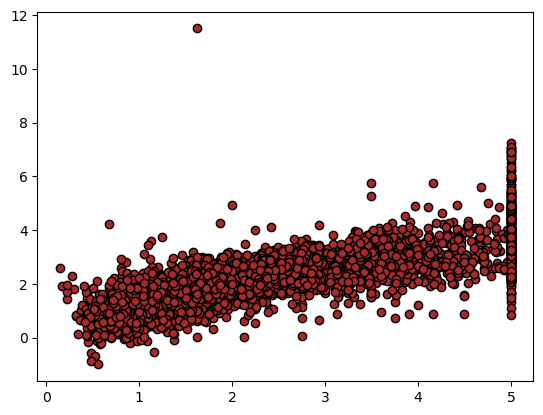

In [ ]:
# Plot a scatter plot for the prediction
plt.scatter(y_test, reg_pred, color="brown", edgecolor="black")

In [ ]:
# Residuals
residuals=y_test-reg_pred

In [ ]:
residuals.mean()

np.float64(-0.0012630658083517788)

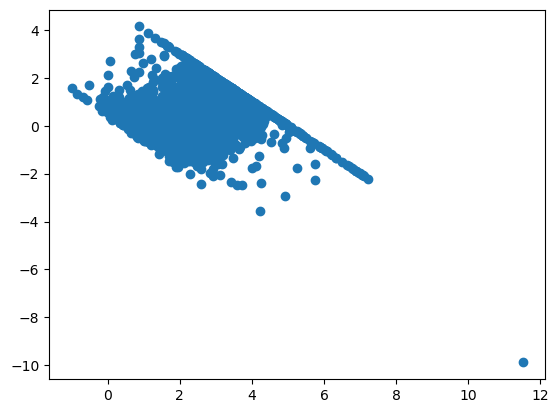

In [ ]:
# Scatter plot with respect to prediction and residuals
# uniform distribution
plt.scatter(reg_pred, residuals)

In [ ]:
residuals

20046   -0.249049
3024    -1.309434
15663    2.289088
20484   -0.649147
9814     0.173042
           ...   
17505    0.155059
13512   -0.237516
10842    0.109345
16559   -0.379714
5786     0.270559
Name: Med_house_value, Length: 6192, dtype: float64

#### Plot residuals

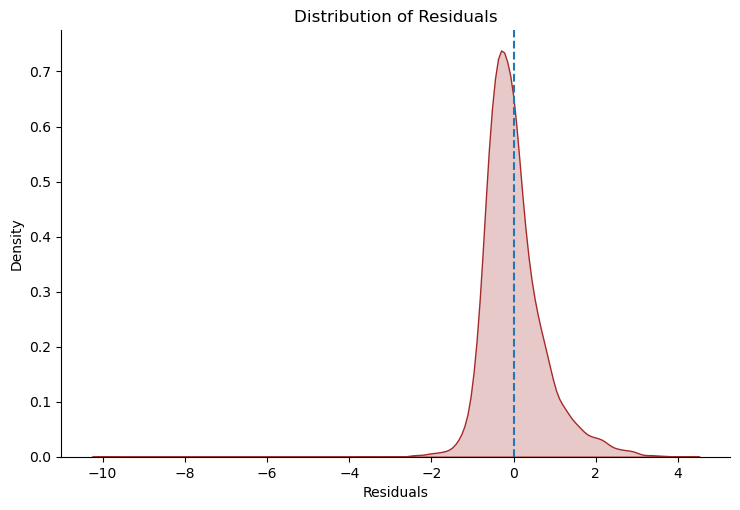

In [ ]:
sns.displot(
    residuals,
    kind="kde",
    fill=True,
    height=5,
    aspect=1.5,
    color="brown"
)

plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("Distribution of Residuals")
plt.axvline(0, linestyle="--")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, reg_pred)
mse = mean_squared_error(y_test, reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, reg_pred)

print("MAE:", mae)
print("MSE", mse)
print("RMSE", rmse)
print("R^2", r2)

MAE: 0.5272474538305952
MSE 0.5305677824766754
RMSE 0.7284008391515453
R^2 0.5957702326061662


#### R square and adjusted R square
Formula
R^2 = 1 = SSR/SST
R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [ ]:
# R squared
r2

0.5957702326061662

##### Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]

In [ ]:
# display adjusted R-squared
1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5952472117200025

#### New Data Prediction

In [ ]:
boston.data[0].reshape(1, -1)

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [ ]:
# transformation of new data
row_for_pred = scaler.transform(boston.data[0].reshape(1,-1))

C:\Users\Rehan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
regression.predict(row_for_pred)

array([4.14333441])

#### Pickling The Model file for Deployement

In [ ]:
import pickle

pickle.dump(regression, open("regmodel.pkl", "wb"))

In [ ]:
pickled_model = pickle.load(open("regmodel.pkl", "rb"))

#### Prediction

In [ ]:
prediction = pickled_model.predict(
    scaler.transform(boston.data[0].reshape(1, -1))
)

print(prediction)

[4.14333441]


C:\Users\Rehan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
